### Ejericicio Clustering 1

Suponer que representamos cada cluster de puntos de dos coordenadas numéricas mediante listas (o arrays).
Definir una función que, dado un cluster y dado un punto adicional (con 2 coordenadas), determine cuál punto del cluster ese el más cercano.

- Sabemos que un cluster es un grupo de puntos o puntos en un eje de coordenadas
- Crear una función que reciba un punto (2, 7) y en base a un cluster de puntos, determinar que punto es el más cercano

#### Input

$$
[
    (1.2, 2.3),
    (4.5, 5.8),
    (1.1, 2.1),
    (9.0, 8.5),
    (2.0, 3.1),
    (4.8, 6.0),
    (0.5, 0.8),
    (8.7, 9.2),
    (5.1, 5.5),
    (1.5, 1.9)
]
$$

$$(4.0, 5.0)$$

#### Output

$$(4.5, 5.8)$$


In [44]:
cluster = [
    (1.2, 2.3),
    (1.5, 2.1),
    (1.1, 2.4),
    (1.3, 2.2),
    (1.4, 2.5),
    (1.6, 2.3),
    (1.2, 2.0),
    (1.7, 2.4),
    (1.3, 2.1),
    (1.5, 2.6),
    (2.0, 3.0),
    (2.1, 3.2),
    (1.9, 3.1),
    (2.2, 3.3),
    (2.0, 3.4),
    (2.3, 3.1),
    (2.1, 3.0),
    (1.8, 3.2),
    (2.2, 3.0),
    (2.0, 3.2),
    (1.0, 1.5),
    (1.2, 1.7),
    (0.9, 1.6),
    (1.1, 1.8),
    (1.3, 1.6),
    (1.0, 1.9),
    (1.4, 1.7),
    (1.2, 1.5),
    (1.1, 1.6),
    (1.3, 1.8),
]

punto_ref = (1.45, 2.35)

In [45]:
# Hay que calcular la dis euclidiana de cada punto con referencia al punto estatico
# La distancia (valor num) mas bajo, es el punto mas cercano
# Devolver ese punto
def calc_punto_cercano(cluster, punto_ref):

    dis_min = float("inf")
    punto_mas_cercano = cluster[0]

    for i in range(len(cluster)):
        punto = cluster[i]
        dis_actual = calc_distancia_euclidiana(punto, punto_ref)

        if dis_min < dis_actual:
            dis_min = dis_actual
            punto_mas_cercano = punto

    return punto_mas_cercano


def calc_distancia_euclidiana(punto_a, punto_b):
    import math

    # La raiz cuadrada de la sumatoria de la diferencia entre 2 puntos al cuadrado
    return math.sqrt(sum((a - b) ** 2 for a, b in zip(punto_a, punto_b)))

calc_punto_cercano(cluster,punto_ref)

(1.2, 2.3)

#### Ejercicio 1B Calcular Centroide Cluster


In [46]:
# El centroide es el promedio de X, promedio de Y
# Ej (4, 21). Es un punto, no un valor numerico
def calc_centroide(cluster):
    return (
        sum([x for x, _ in cluster]) / len(cluster),
        sum([y for _, y in cluster]) / len(cluster),
    )
    
calc_centroide(cluster)

(1.53, 2.3699999999999997)

# Ejericicio Clustering 2

Calcular dado un cluster, su radio y su diametro

Input

$$
[
    (1.2, 2.3),
    (4.5, 5.8),
    (1.1, 2.1),
    (9.0, 8.5),
    (2.0, 3.1),
    (4.8, 6.0),
    (0.5, 0.8),
    (8.7, 9.2),
    (5.1, 5.5),
    (1.5, 1.9)
]
$$

Output
$$Radio: 5.0$$
$$Diametro: 10.0$$


In [47]:
# La distancia mas grande entre un punto del cluster y su centroide
# El radio de un cluster es la máxima distancia de los puntos del cluster a su centroide
# 1. Calcular centroide del cluster
# 2. Buscar de todos los puntos que distancia es la mayor de todas contra el cluster AKA Distancia Euclidiana
# 3. Devolver el radio (max distancia)
def calc_radio_cluster(cluster):

    max_distancia = float("-inf")

    centroide = calc_centroide(cluster)

    for i in range(len(cluster)):
        punto = cluster[i]

        dis_euclidiana = calc_distancia_euclidiana(punto, centroide)

        if dis_euclidiana > max_distancia:
            max_distancia = dis_euclidiana

    radio = max_distancia

    return radio


# La distancia mas grande entre 2 puntos del mismo cluster
# 1. Buscar un maximo valor de distancia euclidiana entre 2 puntos de un cluster
# 2. Comparar cada valor con el siguiente y guardar la distancia si esa es mayor que la anterior
# 3. Devolver el diametro
def calc_diametro_cluster(cluster):

    max_distancia = float("-inf")

    for i in range(len(cluster)):
        punto = cluster[i]

        for j in range(i + 1, len(cluster)):
            punto_sig = cluster[j]

            distancia = calc_distancia_euclidiana(punto, punto_sig)

            if distancia > max_distancia:
                max_distancia = distancia

            # print(f"Distancia {punto} -> {punto_sig}: {distancia}")

    diametro = max_distancia

    return diametro


radio = calc_radio_cluster(cluster)
diametro = calc_diametro_cluster(cluster)

radio, diametro

(1.146211149832351, 2.1633307652783933)

#### 2B Graficando clusters

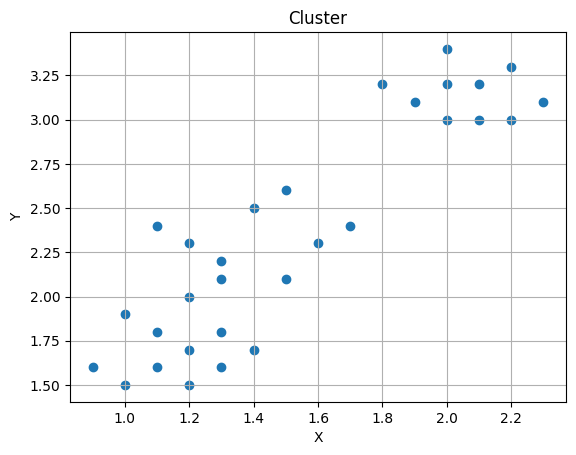

In [48]:
import matplotlib.pyplot as plt
import numpy as np

x = [x for x, _ in cluster]
y = [y for _, y in cluster]


plt.scatter(x, y)
plt.title("Cluster")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid()
plt.show()

#### 2C K-means clustering

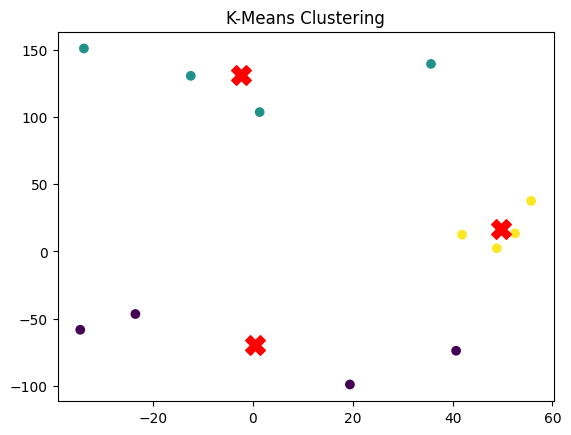

In [49]:
from sklearn.cluster import KMeans
import pandas as pd
from matplotlib import pyplot as plt

x = [x for x, _ in cluster]
y = [y for _, y in cluster]


df = pd.read_csv("./data.csv")

kmeans = KMeans(3)

kmeans.fit(df[["latitude", "longitude"]])

labels = kmeans.labels_
centroids = kmeans.cluster_centers_

df["cluster"] = labels

plt.scatter(df["latitude"], df["longitude"], c=kmeans.labels_)

centroids = kmeans.cluster_centers_

plt.scatter(centroids[:, 0], centroids[:, 1], c="red", marker="X", s=200)
plt.title("K-Means Clustering")
plt.show()

### Ejercicio 3

Escribir un script que (sobre un ejemplo como el anterior) calcule KMeans con distintos valores de k (n_clusters) desde un mínimo hasta un máximo, y determine el mejor k, en el sentido de que sea mínima la varianza entre los diámetros de los clusters obtenidos.

Input:
$$Dataframe$$
Output:
$$kmeans$$

In [54]:
from sklearn.cluster import KMeans
import pandas as pd
def calc_varianza(diametros):

    promedio = sum(diametros) / len(diametros)

    total = 0
    for diametro in diametros:
        total += (diametro - promedio) ** 2

    varianza = total / (len(diametros) - 1) 

    return varianza


def calc_kmeans(df, min_k, max_k):

    varianza_min = float("inf")
    mejor_k = min_k

    for k in range(min_k, max_k + 1):
        kmeans = KMeans(n_clusters=k)
        kmeans.fit(df)
        
        df = df.copy()

        df["cluster_id"] = kmeans.labels_

        diametros = []
        for cluster_id in df["cluster_id"].unique():

            cluster_filtrado = df[df["cluster_id"] == cluster_id]

            diametro = calc_diametro_cluster(
                cluster_filtrado[["latitude", "longitude"]].values.tolist()
            )

            diametros.append(diametro)

        varianza = calc_varianza(diametros)

        if varianza < varianza_min:
            varianza_min = varianza
            mejor_k = k

    return mejor_k


df = pd.read_csv("data.csv")
df = df.drop(columns=["id"])

mejor_k = calc_kmeans(df[["latitude", "longitude"]], 2, 7)
print(f"El mejor valor de k es: {mejor_k}")

El mejor valor de k es: 3


EXTRA: Agregar un punto al cluster y ver como cambian los centroides